In [1]:
import re
import pandas as pd
import seaborn as sns
from langfuse import Langfuse
import matplotlib.pyplot as plt

from polylex_chatbot.env import load_project_env

env_path = load_project_env()

In [2]:
langfuse = Langfuse()
DATASET_NAME = "20250520_clean_dev_dataset"
dataset = langfuse.get_dataset(DATASET_NAME)
RUN_NAME = "2026-06-18T16:29:10.736900-rag"

In [3]:
run = langfuse.get_dataset_run(
    dataset_name=DATASET_NAME,
    run_name=RUN_NAME
)
trace_ids = [item.trace_id for item in run.dataset_run_items]
results = [langfuse.api.trace.get(trace_id).scores for trace_id in trace_ids]

In [4]:
def langfuse_scores_to_df(results):
    rows = []

    for result in results:
        for metric in result:
            rows.append({
                "trace_id": metric.observation_id,
                "metric": metric.name,
                "value": metric.value
            })

    df_long = pd.DataFrame(rows)

    df_wide = (
        df_long
        .pivot_table(
            index=["trace_id"],
            columns="metric",
            values="value",
            aggfunc="first"
        )
        .reset_index()
    )

    df_wide.columns.name = None

    return df_wide

In [5]:
df_scores = langfuse_scores_to_df(results)

ordered_cols = [
    "trace_id",
    "hit_at_1",
    "hit_at_2",
    "hit_at_3",
    "hit_at_4",
    "hit_at_5",
    "hit_at_10",
    "hit_at_15",
    "hit_at_20",
    "mrr_doc",
    "nb_correct_doc",
    "chrf_score",
    "len_ratio_answers",
    "Context Relevance (Contextrelevance-Langfuse)",
    "Groundedness (Faithfulness-RAGAS)",
    "Answer Relevance (Relevance-Langfuse)",
    "Answer Correctness - RAGAS"
]

remaining_cols = [col for col in df_scores.columns if col not in ordered_cols]
df_scores_ordered = df_scores[[col for col in ordered_cols if col in df_scores.columns]]

df_scores_ordered

,trace_id,hit_at_1,hit_at_2,hit_at_3,hit_at_4,hit_at_5,hit_at_10,hit_at_15,hit_at_20,mrr_doc,nb_correct_doc,chrf_score,len_ratio_answers,Context Relevance (Contextrelevance-Langfuse),Groundedness (Faithfulness-RAGAS),Answer Relevance (Relevance-Langfuse),Answer Correctness - RAGAS
0,002974f8d32069fa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.197827,3.138614,0.0,1.00,1.0,8.500000e-01
1,0d56cc8aeda90ec8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,6.0,0.269767,1.078431,1.0,0.75,1.0,0.000000e+00
2,136a01dd5fceee9a,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.250000,1.0,0.500522,0.661238,1.0,1.00,1.0,8.500000e-01
3,2da5156df8959f02,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,2.0,0.275167,0.118321,1.0,1.00,1.0,9.800000e-01
4,47dfeb25d9b0d24a,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,2.0,0.461008,0.393539,1.0,1.00,1.0,8.500000e-01
5,5d8885c9176592ae,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.142857,3.0,0.413623,0.689394,0.0,1.00,0.9,9.500000e-01
6,672eae6d4377fe9a,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,4.0,0.095605,0.025907,1.0,0.80,1.0,1.000000e+02
7,7186807ed5438482,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,6.0,0.445911,0.364706,1.0,1.00,1.0,1.000000e+00
8,7a381bc1a978eece,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,5.0,0.047715,8.440000,1.0,1.00,1.0,1.000000e-15
9,9de8ecbc1fcdafc1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,4.0,0.122785,0.272727,1.0,1.00,0.9,5.454545e-02


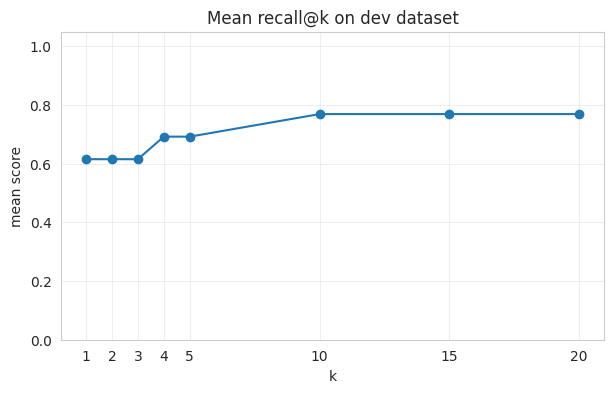

In [6]:
# hit@k

recall_cols = [col for col in df_scores_ordered.columns if re.match(r"^hit_at_\d+$", col)]

recall_df = pd.DataFrame({
    "k": [int(col.split("_")[-1]) for col in recall_cols],
    "mean_recall": [df_scores_ordered[col].mean() for col in recall_cols],
}).sort_values("k")

plt.figure(figsize=(7, 4))
plt.plot(
    recall_df["k"],
    recall_df["mean_recall"],
    marker="o",
)

plt.xlabel("k")
plt.ylabel("mean score")
plt.title("Mean recall@k on dev dataset")
plt.xticks(recall_df["k"])
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

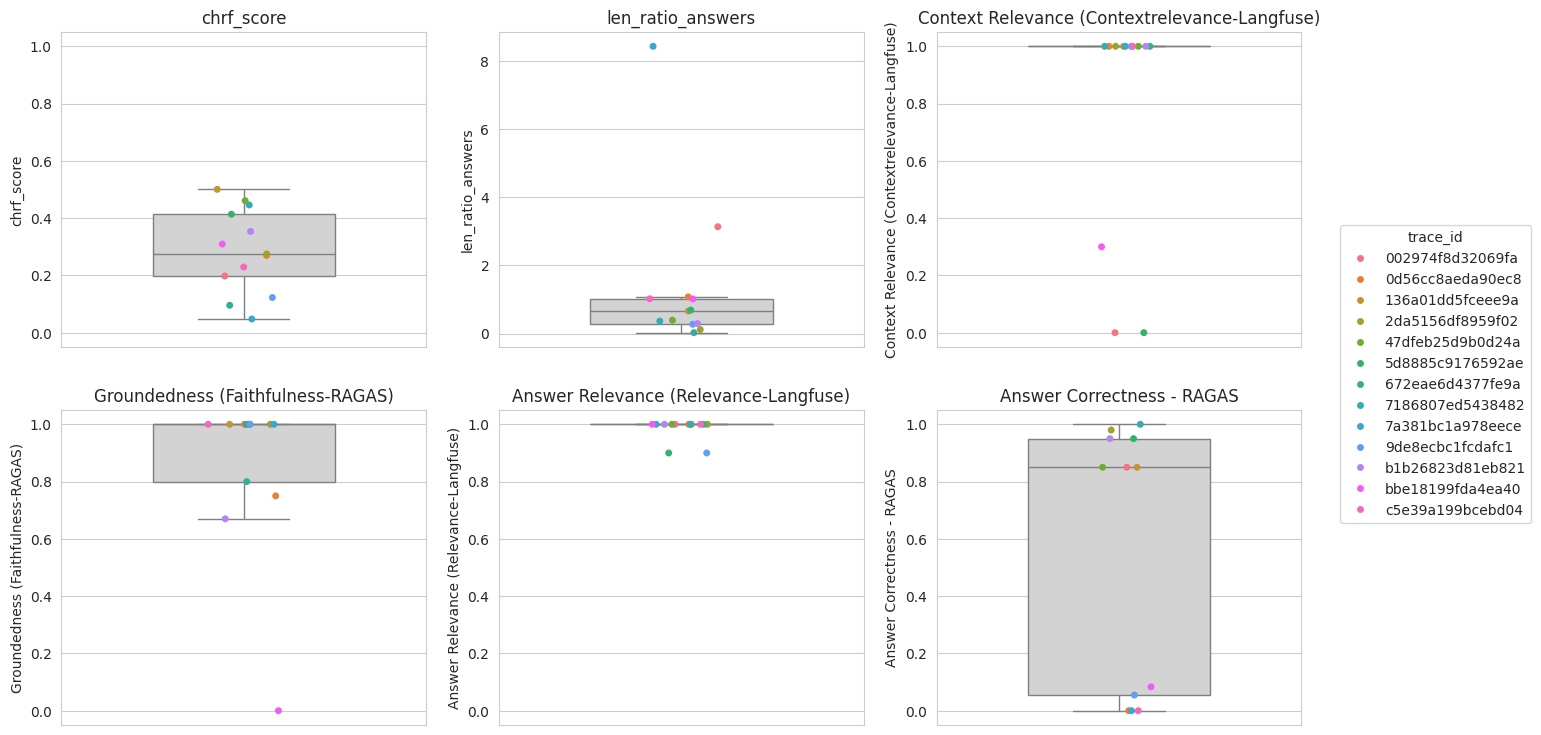

In [7]:
def plot_boxplots_grid(df, cols, y_limits=None):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    hue_order = pd.unique(df["trace_id"])

    legend_handles = None
    legend_labels = None

    for ax, col in zip(axes, cols):
        sns.boxplot(
            data=df,
            y=col,
            color="lightgray",
            showfliers=False,
            width=0.5,
            ax=ax
        )

        sns.stripplot(
            data=df,
            y=col,
            hue="trace_id",
            hue_order=hue_order,
            jitter=True,
            ax=ax
        )

        ax.set_title(f"{col}")
        ax.set_ylabel(col)
        ax.set_xlabel("")

        if y_limits and col in y_limits:
            y_min, y_max = y_limits[col]
            ax.set_ylim(y_min - 0.05, y_max + 0.05)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    fig.legend(
        legend_handles,
        legend_labels,
        title="trace_id",
        bbox_to_anchor=(0.92, 0.5),
        loc="center left"
    )

    plt.show()

cols = [
    "chrf_score",
    "len_ratio_answers",
    "Context Relevance (Contextrelevance-Langfuse)",
    "Groundedness (Faithfulness-RAGAS)",
    "Answer Relevance (Relevance-Langfuse)",
    "Answer Correctness - RAGAS"
]

y_limits = {
    "chrf_score": (0, 1),
    "Context Relevance (Contextrelevance-Langfuse)": (0, 1),
    "Groundedness (Faithfulness-RAGAS)": (0, 1),
    "Answer Relevance (Relevance-Langfuse)": (0, 1),
    "Answer Correctness - RAGAS": (0, 1)
}

plot_boxplots_grid(df_scores_ordered, cols, y_limits)

# TODO : dans Langfuse, aller sous Tracing puis Observations et filtrer avec metadata: target_observation_id = trace_id